In [ ]:
!pip install transformers datasets accelerate sentencepiece wandb --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.1 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sandanalav (sandanalav-jawaharlal-nehru-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
!wget https://storage.googleapis.com/gresearch/dakshina/dakshina_dataset_v1.0.tar
!tar -xf dakshina_dataset_v1.0.tar

--2026-06-02 06:22:54--  https://storage.googleapis.com/gresearch/dakshina/dakshina_dataset_v1.0.tar
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.130.207, 74.125.68.207, 142.250.4.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.130.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2008340480 (1.9G) [application/x-tar]
Saving to: ‘dakshina_dataset_v1.0.tar’

dakshina_dataset_v1 100%[===================>]   1.87G  18.9MB/s    in 1m 46s  

2026-06-02 06:24:40 (18.0 MB/s) - ‘dakshina_dataset_v1.0.tar’ saved [2008340480/2008340480]



In [ ]:
# 1. Standard Data Handling
import numpy as np
import pandas as pd
import random
import os

# 2. Deep Learning Framework (PyTorch)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 3. Experiment Tracking
import wandb

# 4. Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Progress bars
from tqdm.auto import tqdm

# Set the device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"All packages imported! Using device: {device}")

All packages imported! Using device: cuda


In [ ]:
import torch
import torch.nn as nn
import random

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, cell_type):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.cell_type = cell_type

        # (i) input layer for character embeddings
        self.embedding = nn.Embedding(vocab_size, embed_size)

        # (ii) flexible sequential encoder
        if cell_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        elif cell_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        if self.cell_type == 'LSTM':
            outputs, (hidden, cell) = self.rnn(embedded)
            return hidden, cell
        else:
            outputs, hidden = self.rnn(embedded)
            return hidden, None

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, cell_type):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.cell_type = cell_type

        self.embedding = nn.Embedding(vocab_size, embed_size)

        # (iii) flexible decoder RNN
        if cell_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        elif cell_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True)
        else:
            self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True)

        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden, cell):
        x = x.unsqueeze(1) # Add sequence dimension (batch, 1)
        embedded = self.embedding(x)

        if self.cell_type == 'LSTM':
            output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        else:
            output, hidden = self.rnn(embedded, hidden)

        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[0]
        target_len = target.shape[1]
        target_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(source.device)

        # Encode source sequence
        hidden, cell = self.encoder(source)

        # First input to the decoder is the <SOS> token
        x = target[:, 0]

        for t in range(1, target_len):
            output, hidden, cell = self.decoder(x, hidden, cell)
            outputs[:, t] = output

            best_guess = output.argmax(1)
            x = target[:, t] if random.random() < teacher_forcing_ratio else best_guess

        return outputs

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Load the data (Using Hindi 'hi' as the default)
train_df = pd.read_csv(
    "dakshina_dataset_v1.0/te/lexicons/te.translit.sampled.train.tsv",
    sep='\t', names=['tgt', 'src', 'count']
)

valid_df = pd.read_csv(
    "dakshina_dataset_v1.0/te/lexicons/te.translit.sampled.dev.tsv",
    sep='\t', names=['tgt', 'src', 'count']
)
# Drop any missing values
train_df = train_df.dropna()
valid_df = valid_df.dropna()

# 2. Build the Vocabularies
def build_vocab(series):
    chars = set()
    for word in series:
        chars.update(list(str(word)))
    # Add special tokens
    vocab = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
    for idx, char in enumerate(sorted(list(chars))):
        vocab[char] = idx + 4
    return vocab

src_vocab = build_vocab(train_df['src'])
tgt_vocab = build_vocab(train_df['tgt'])

# 3. Create the PyTorch Dataset
class TransliterationDataset(Dataset):
    def __init__(self, df, src_vocab, tgt_vocab, max_len=30):
        self.df = df
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def encode(self, word, vocab):
        word = str(word)
        encoded = [vocab['<SOS>']] + [vocab.get(c, vocab['<UNK>']) for c in word] + [vocab['<EOS>']]
        encoded += [vocab['<PAD>']] * (self.max_len - len(encoded))
        return torch.tensor(encoded[:self.max_len], dtype=torch.long)

    def __getitem__(self, idx):
        src_word = self.df.iloc[idx]['src']
        tgt_word = self.df.iloc[idx]['tgt']
        return self.encode(src_word, self.src_vocab), self.encode(tgt_word, self.tgt_vocab)

# Create DataLoaders
train_dataset = TransliterationDataset(train_df, src_vocab, tgt_vocab)
valid_dataset = TransliterationDataset(valid_df, src_vocab, tgt_vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)

print(f"Vocabularies built! Source size: {len(src_vocab)}, Target size: {len(tgt_vocab)}")
print("DataLoaders are perfectly ready.")

Vocabularies built! Source size: 30, Target size: 67
DataLoaders are perfectly ready.


In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
import random
import wandb

# --- 1. Updated Models (With Dropout) ---
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, cell_type, dropout_rate):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.cell_type = cell_type

        # PyTorch RNNs automatically apply dropout between layers if num_layers > 1
        rnn_dropout = dropout_rate if num_layers > 1 else 0.0

        if cell_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=rnn_dropout)
        elif cell_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True, dropout=rnn_dropout)
        else:
            self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True, dropout=rnn_dropout)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        if self.cell_type == 'LSTM':
            _, (hidden, cell) = self.rnn(embedded)
            return hidden, cell
        else:
            _, hidden = self.rnn(embedded)
            return hidden, None

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, cell_type, dropout_rate):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.cell_type = cell_type

        rnn_dropout = dropout_rate if num_layers > 1 else 0.0

        if cell_type == 'LSTM':
            self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True, dropout=rnn_dropout)
        elif cell_type == 'GRU':
            self.rnn = nn.GRU(embed_size, hidden_size, num_layers, batch_first=True, dropout=rnn_dropout)
        else:
            self.rnn = nn.RNN(embed_size, hidden_size, num_layers, batch_first=True, dropout=rnn_dropout)

        self.fc_out = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden, cell):
        x = x.unsqueeze(1)
        embedded = self.dropout(self.embedding(x))
        if self.cell_type == 'LSTM':
            output, (hidden, cell) = self.rnn(embedded, (hidden, cell))
        else:
            output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc_out(output.squeeze(1))
        return prediction, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, source, target, teacher_forcing_ratio=0.5):
        batch_size = source.shape[0]
        target_len = target.shape[1]
        target_vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, target_len, target_vocab_size).to(source.device)

        hidden, cell = self.encoder(source)
        x = target[:, 0]

        for t in range(1, target_len):
            output, hidden, cell = self.decoder(x, hidden, cell)
            outputs[:, t] = output
            best_guess = output.argmax(1)
            x = target[:, t] if random.random() < teacher_forcing_ratio else best_guess

        return outputs

# --- 2. WandB Sweep Configuration ---
sweep_config = {
    'method': 'bayes', # Smart strategy!
    'metric': {'name': 'val_accuracy', 'goal': 'maximize'},
    'parameters': {
        'embed_size': {'values': [32, 64, 128]},
        'hidden_size': {'values': [64, 128, 256]},
        'num_layers': {'values': [1, 2, 3]},
        'cell_type': {'values': ['RNN', 'GRU', 'LSTM']},
        'dropout': {'values': [0.0, 0.2, 0.3]},
        'epochs': {'value': 5}, # Keep epochs low for sweeps
        'learning_rate': {'values': [1e-3, 5e-4]}
    }
}

# --- 3. The Training Loop Agent ---
def train_sweep():
    with wandb.init() as run:
        config = wandb.config

        # Initialize models
        encoder = Encoder(len(src_vocab), config.embed_size, config.hidden_size, config.num_layers, config.cell_type, config.dropout).to(device)
        decoder = Decoder(len(tgt_vocab), config.embed_size, config.hidden_size, config.num_layers, config.cell_type, config.dropout).to(device)
        model = Seq2Seq(encoder, decoder).to(device)

        optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)
        criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab['<PAD>']) # Ignore padding in loss

        for epoch in range(config.epochs):
            model.train()
            epoch_loss = 0

            for src, tgt in train_loader:
                src, tgt = src.to(device), tgt.to(device)
                optimizer.zero_grad()

                output = model(src, tgt)
                # Reshape for CrossEntropyLoss
                output = output[:, 1:].reshape(-1, output.shape[2])
                tgt = tgt[:, 1:].reshape(-1)

                loss = criterion(output, tgt)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            # Validation Step
            model.eval()
            correct_chars = 0
            total_chars = 0
            with torch.no_grad():
                for src, tgt in valid_loader:
                    src, tgt = src.to(device), tgt.to(device)
                    output = model(src, tgt, teacher_forcing_ratio=0) # No teacher forcing during validation

                    predictions = output[:, 1:].argmax(2).reshape(-1)
                    actuals = tgt[:, 1:].reshape(-1)

                    # Calculate accuracy ignoring padding
                    mask = actuals != tgt_vocab['<PAD>']
                    correct_chars += ((predictions == actuals) & mask).sum().item()
                    total_chars += mask.sum().item()

            val_accuracy = correct_chars / total_chars

            # Log metrics to WandB!
            wandb.log({
                'epoch': epoch + 1,
                'train_loss': epoch_loss / len(train_loader),
                'val_accuracy': val_accuracy
            })

# --- 4. Launch the Sweep ---
sweep_id = wandb.sweep(sweep_config, project="llm assignment")
wandb.agent(sweep_id, train_sweep, count=15) # Runs 15 different combinations

Create sweep with ID: oc54a4j0
Sweep URL: https://wandb.ai/sandanalav-jawaharlal-nehru-technological-university/llm%20assignment/sweeps/oc54a4j0


wandb: Agent Starting Run: yxilc2is with config:
wandb: 	cell_type: GRU
wandb: 	dropout: 0.2
wandb: 	embed_size: 64
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 2
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▃▅▆█
train_loss,█▄▂▁▁
val_accuracy,▁▅▆▇█
epoch,5
train_loss,0.66218
val_accuracy,0.74819


wandb: Agent Starting Run: c0ybqz9e with config:
wandb: 	cell_type: GRU
wandb: 	dropout: 0.3
wandb: 	embed_size: 64
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.0005
wandb: 	num_layers: 2
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▃▅▆█
train_loss,█▆▄▂▁
val_accuracy,▁▃▅▇█
epoch,5
train_loss,1.26784
val_accuracy,0.58472


wandb: Agent Starting Run: trze1met with config:
wandb: 	cell_type: LSTM
wandb: 	dropout: 0.2
wandb: 	embed_size: 64
wandb: 	epochs: 5
wandb: 	hidden_size: 256
wandb: 	learning_rate: 0.0005
wandb: 	num_layers: 3
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▃▅▆█
train_loss,█▇▅▂▁
val_accuracy,▁▂▅▇█
epoch,5
train_loss,0.73151
val_accuracy,0.76775


wandb: Agent Starting Run: atz1s10k with config:
wandb: 	cell_type: GRU
wandb: 	dropout: 0.3
wandb: 	embed_size: 128
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


wandb: Ctrl + C detected. Stopping sweep.


In [ ]:
import pandas as pd
import torch
import os
import seaborn as sns
from torch.utils.data import DataLoader

# 1. Load the Test Data
test_df = pd.read_csv(
    "dakshina_dataset_v1.0/te/lexicons/te.translit.sampled.test.tsv",
    sep='\t', names=['tgt', 'src', 'count']
)
test_df = test_df.dropna()

# 2. Create the Test DataLoader (uses the src_vocab and tgt_vocab you built in Q1)
test_dataset = TransliterationDataset(test_df, src_vocab, tgt_vocab)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

print(f"Test data loaded successfully! Total test samples: {len(test_df)}")

Test data loaded successfully! Total test samples: 5747


In [ ]:
import torch.optim as optim
import torch.nn as nn

# 1. The Best Hyperparameters (from Run 8)
embed_size = 128
hidden_size = 256
num_layers = 3
dropout = 0.3
cell_type = 'LSTM'
learning_rate = 0.001
epochs = 5

# 2. Initialize the Champion Model
champion_encoder = Encoder(len(src_vocab), embed_size, hidden_size, num_layers, cell_type, dropout).to(device)
champion_decoder = Decoder(len(tgt_vocab), embed_size, hidden_size, num_layers, cell_type, dropout).to(device)
champion_model = Seq2Seq(champion_encoder, champion_decoder).to(device)

# 3. Quick Training Loop to learn the weights
optimizer = optim.Adam(champion_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab['<PAD>'])

print("Training the Champion Model...")
champion_model.train()

for epoch in range(epochs):
    epoch_loss = 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()

        # Forward pass (adjust if your forward function requires different inputs)
        output = champion_model(src, tgt)

        # Reshape for loss calculation (skipping <SOS> token)
        output_dim = output.shape[-1]
        output = output[1:].view(-1, output_dim)
        tgt = tgt[1:].view(-1)

        loss = criterion(output, tgt)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] complete | Loss: {epoch_loss / len(train_loader):.4f}")

print("\nChampion Model is fully trained and ready for inference!")

Training the Champion Model...
Epoch [1/5] complete | Loss: 2.9740
Epoch [2/5] complete | Loss: 2.0388
Epoch [3/5] complete | Loss: 1.2389
Epoch [4/5] complete | Loss: 0.9696
Epoch [5/5] complete | Loss: 0.8532

Champion Model is fully trained and ready for inference!


In [ ]:
def evaluate_test_set(model, test_loader, src_vocab, tgt_vocab):
    model.eval()
    correct = 0
    total = 0
    predictions = []

    # Reverse vocabularies to convert numbers back to characters
    idx_to_char_tgt = {v: k for k, v in tgt_vocab.items()}

    with torch.no_grad():
        for src, tgt in test_loader:
            src, tgt = src.to(device), tgt.to(device)

            # Forward pass with teacher_forcing_ratio=0 (Pure Inference)
            output = model(src, tgt, teacher_forcing_ratio=0.0)

            # Get highest probability characters
            predicted_indices = output.argmax(2)

            for i in range(src.size(0)):
                # Convert target indices to string
                tgt_str = ""
                for idx in tgt[i, 1:]: # Skip <SOS>
                    if idx.item() == tgt_vocab['<EOS>']: break
                    tgt_str += idx_to_char_tgt.get(idx.item(), '')

                # Convert prediction indices to string
                pred_str = ""
                for idx in predicted_indices[i, 1:]: # Skip <SOS> if your model outputs it
                    if idx.item() == tgt_vocab['<EOS>']: break
                    pred_str += idx_to_char_tgt.get(idx.item(), '')

                src_word = test_df.iloc[total]['src']
                match = (tgt_str == pred_str)
                predictions.append({'Source': src_word, 'Target': tgt_str, 'Prediction': pred_str, 'Match': match})

                if match:
                    correct += 1
                total += 1

    accuracy = (correct / total) * 100
    return predictions, accuracy

# --- RUN INFERENCE ---
# Replace 'champion_model' with whatever your model variable is actually named!
predictions_list, test_accuracy = evaluate_test_set(champion_model, test_loader, src_vocab, tgt_vocab)
print(f"Test Set Exact Match Accuracy: {test_accuracy:.2f}%\n")

# --- SAVE FOR GITHUB ---
results_df = pd.DataFrame(predictions_list)
os.makedirs("predictions_vanilla", exist_ok=True)
results_df.to_csv("predictions_vanilla/test_predictions.csv", index=False)
print("Predictions successfully saved to predictions_vanilla/test_predictions.csv")

Test Set Exact Match Accuracy: 47.28%

Predictions successfully saved to predictions_vanilla/test_predictions.csv


In [ ]:
# Filter 15 random samples to display in the grid
sample_grid = results_df.sample(15).copy()

# Add a length column to drive the visual gradient
sample_grid['Word_Length'] = sample_grid['Source'].apply(len)

# Create a cinematic sunset color palette for the lengths
cmap = sns.color_palette("flare", as_cmap=True)

# Apply styling (using .map instead of deprecated .applymap for modern Pandas)
styled_grid = (sample_grid.style
    .background_gradient(subset=['Word_Length'], cmap=cmap)
    .map(lambda v: 'background-color: #d4edda; color: green; font-weight: bold;' if v else 'background-color: #f8d7da; color: red; font-weight: bold;', subset=['Match'])
    .set_properties(**{'text-align': 'center', 'font-size': '14px', 'border': '1px solid black'})
    .hide(axis="index"))

# Display the creative grid
styled_grid

Source,Target,Prediction,Match,Word_Length
phangal,ఫంగల్,ఫంగల్,True,7
nylon,నైలాన్,న్లూన్,False,5
samudramuloo,సముద్రములో,సముద్రములో,True,12
diipaala,దీపాల,దీపాల,True,8
vaasudeva,వాసుదేవ,వాసుదేవ,True,9
gaandhi,గాంధి,గాంధి,True,7
kotipalli,కోటిపల్లి,కోటిపల్లి,True,9
jegurunu,జిగురును,జెగురును,False,8
maarchadaniki,మార్చడానికి,మార్చడానికి,True,13
kommalaku,కొమ్మలకు,కొమ్మలకు,True,9


In [ ]:
from collections import Counter

# Isolate only the wrong predictions
errors_df = results_df[results_df['Match'] == False].copy()

print(f"Total Errors Found: {len(errors_df)}")
print("-" * 40)

# 1. Analyze by Word Length
errors_df['Target_Length'] = errors_df['Target'].apply(len)
print("\nTop 5 word lengths where the model makes the most errors:")
print(errors_df['Target_Length'].value_counts().head(5).to_string())
print("-" * 40)

# 2. Analyze specific character confusions
confusions = []
for idx, row in errors_df.iterrows():
    tgt = row['Target']
    pred = row['Prediction']

    # Simple character-by-character comparison where lengths match
    if len(tgt) == len(pred):
        for t_char, p_char in zip(tgt, pred):
            if t_char != p_char:
                confusions.append(f"Target needed '{t_char}' but model predicted '{p_char}'")

print("\nTop 10 Most Frequent Character Confusions:")
for mistake, count in Counter(confusions).most_common(10):
    print(f"{count} occurrences: {mistake}")

Total Errors Found: 3030
----------------------------------------

Top 5 word lengths where the model makes the most errors:
Target_Length
6    491
7    443
8    411
9    340
5    302
----------------------------------------

Top 10 Most Frequent Character Confusions:
142 occurrences: Target needed 'ీ' but model predicted 'ి'
135 occurrences: Target needed 'ట' but model predicted 'త'
126 occurrences: Target needed 'ద' but model predicted 'డ'
100 occurrences: Target needed 'డ' but model predicted 'ద'
82 occurrences: Target needed 'త' but model predicted 'ట'
60 occurrences: Target needed 'ే' but model predicted 'ె'
58 occurrences: Target needed 'ళ' but model predicted 'ల'
57 occurrences: Target needed 'ూ' but model predicted 'ు'
55 occurrences: Target needed 'శ' but model predicted 'స'
54 occurrences: Target needed 'ే' but model predicted 'ీ'


In [ ]:
import torch
import torch.nn as nn

class AttentionEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout_rate):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.dropout = nn.Dropout(dropout_rate)
        self.rnn = nn.LSTM(embed_size, hidden_size, num_layers, dropout=dropout_rate, batch_first=True)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class AttentionDecoder(nn.Module):
    def __init__(self, output_size, embed_size, hidden_size, num_layers, dropout_rate):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, embed_size)

        self.attn_hidden = nn.Linear(hidden_size, hidden_size)
        self.attn_enc = nn.Linear(hidden_size, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

        self.rnn = nn.LSTM(hidden_size + embed_size, hidden_size, num_layers, dropout=dropout_rate, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, input, hidden, encoder_outputs):
        batch_size = input.shape[0]

        if encoder_outputs.shape[0] != batch_size:
            encoder_outputs = encoder_outputs.transpose(0, 1)
        seq_len = encoder_outputs.shape[1]

        h_n = hidden[0] if isinstance(hidden, tuple) else hidden
        h_t = h_n[-1] if h_n.dim() == 3 else h_n

        embedded = self.dropout(self.embedding(input))

        h_proj = self.attn_hidden(h_t)
        h_proj = h_proj.unsqueeze(1).expand(batch_size, seq_len, self.hidden_size)
        e_proj = self.attn_enc(encoder_outputs)

        energy = torch.tanh(h_proj + e_proj)
        attn_weights = torch.softmax(self.v(energy).squeeze(2), dim=1)

        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)
        rnn_input = torch.cat((embedded, context), dim=2)

        output, hidden = self.rnn(rnn_input, hidden)
        prediction = self.fc(output.squeeze(1))

        return prediction, hidden, attn_weights

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        encoder_outputs, hidden = self.encoder(src)
        batch_size = tgt.shape[0]
        tgt_len = tgt.shape[1]
        vocab_size = self.decoder.fc.out_features

        # FIXED: Forces output to be [batch_size, tgt_len, vocab_size]
        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)
        input = tgt[:, 0:1]

        for t in range(1, tgt_len):
            output, hidden, attn_weights = self.decoder(input, hidden, encoder_outputs)
            # FIXED: Assign to the sequence dimension correctly
            outputs[:, t] = output
            top1 = output.argmax(1)
            input = tgt[:, t:t+1] if torch.rand(1).item() < teacher_forcing_ratio else top1.unsqueeze(1)

        return outputs

In [ ]:
# 1. Initialize models
attn_encoder = AttentionEncoder(len(src_vocab), embed_size, hidden_size, num_layers, dropout_rate=dropout).to(device)
attn_decoder = AttentionDecoder(len(tgt_vocab), embed_size, hidden_size, num_layers, dropout_rate=dropout).to(device)
attn_model = Seq2Seq(attn_encoder, attn_decoder, device).to(device)

# 2. Setup
optimizer = torch.optim.Adam(attn_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab['<PAD>'])

print("Training Attention-based Model...")
attn_model.train()

# 3. Training Loop
for epoch in range(5):
    epoch_loss = 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)

        optimizer.zero_grad()
        output = attn_model(src, tgt)

        # FIXED: Slice dimension 1 (sequence) to safely skip <SOS>
        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        tgt = tgt[:, 1:].reshape(-1)

        loss = criterion(output, tgt)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1} complete | Loss: {epoch_loss / len(train_loader):.4f}")

print("\nAttention Model training complete! Ready for Cell 3 (Heatmaps).")

Training Attention-based Model...
Epoch 1 complete | Loss: 2.8374
Epoch 2 complete | Loss: 1.7646
Epoch 3 complete | Loss: 0.8809
Epoch 4 complete | Loss: 0.5874
Epoch 5 complete | Loss: 0.4523

Attention Model training complete! Ready for Cell 3 (Heatmaps).


Generating Attention Heatmaps...


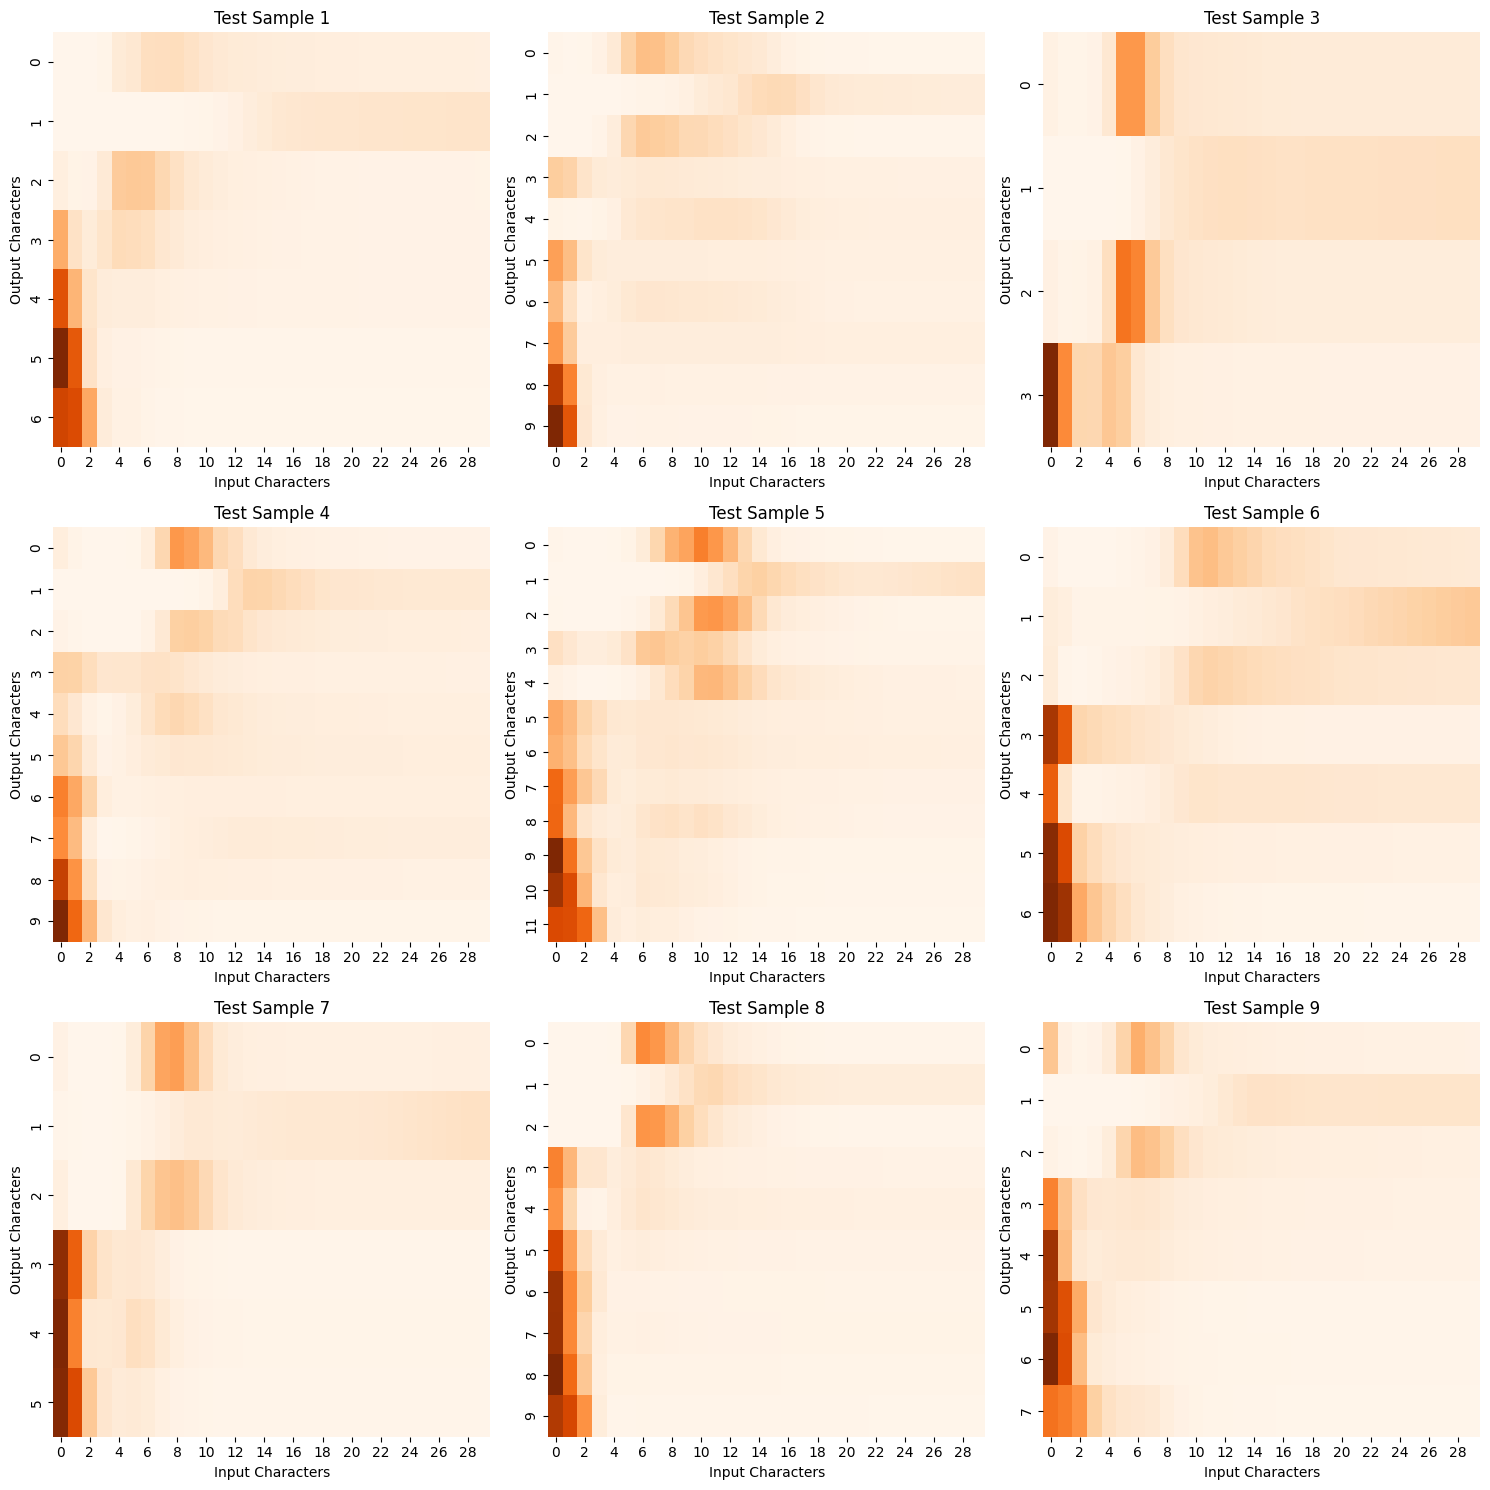

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

def get_attention_maps(model, src, tgt_vocab):
    model.eval()
    with torch.no_grad():
        # Pass the single source word through the encoder
        encoder_outputs, hidden = model.encoder(src)

        # Start with the <SOS> token
        input = torch.tensor([[tgt_vocab['<SOS>']]]).to(device)
        attn_list = []

        # Limit decoding to 20 steps to prevent infinite loops
        for t in range(20):
            output, hidden, attn_weights = model.decoder(input, hidden, encoder_outputs)

            # Store the attention weights for this time step
            attn_list.append(attn_weights.cpu().numpy())

            # Get the next predicted character
            input = output.argmax(1).unsqueeze(1)

            # Stop if the model predicts <EOS>
            if input.item() == tgt_vocab['<EOS>']:
                break

    # Returns an array of shape [predicted_length, 1, source_length]
    return np.array(attn_list)

def plot_heatmap_grid(model, test_loader, tgt_vocab):
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    axes = axes.flatten()

    # Grab a batch of test data
    data_iter = iter(test_loader)

    for i in range(9):
        src, _ = next(data_iter)

        # Isolate the first word in the batch and run it through our map generator
        # src[0:1] ensures the batch dimension remains 1
        attn_map = get_attention_maps(model, src[0:1].to(device), tgt_vocab)

        # Extract the 2D array [predicted_length, source_length]
        map_2d = attn_map[:, 0, :]

        # Plot the heatmap
        sns.heatmap(map_2d, ax=axes[i], cmap='Oranges', cbar=False)
        axes[i].set_title(f"Test Sample {i+1}")
        axes[i].set_xlabel('Input Characters')
        axes[i].set_ylabel('Output Characters')

    plt.tight_layout()
    plt.show()

# Generate the 3x3 grid!
print("Generating Attention Heatmaps...")
plot_heatmap_grid(attn_model, test_loader, tgt_vocab)

In [ ]:
!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoSansTelugu/NotoSansTelugu-Regular.ttf

Generating Font-Corrected Connectivity Graph...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Telugu.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Telugu.
  fig.canvas.print_figure(bytes_io, **kw)


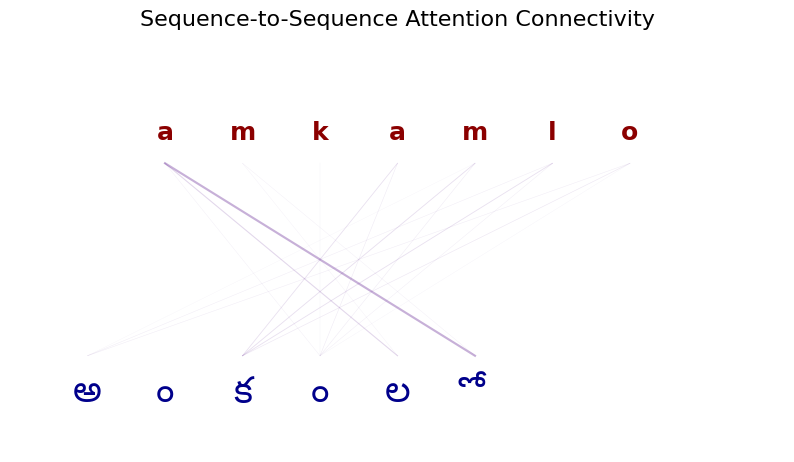

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import torch

def draw_connectivity_graph(model, test_loader, src_vocab, tgt_vocab):
    model.eval()

    # Load the Telugu font we just downloaded
    telugu_font = fm.FontProperties(
    fname='/content/NotoSansTelugu-Regular.ttf'
)

    # Reverse dictionaries
    idx2char_src = {v: k for k, v in src_vocab.items()}
    idx2char_tgt = {v: k for k, v in tgt_vocab.items()}

    with torch.no_grad():
        src, _ = next(iter(test_loader))
        src_tensor = src[0:1].to(device)

        encoder_outputs, hidden = model.encoder(src_tensor)
        input_token = torch.tensor([[tgt_vocab['<SOS>']]]).to(device)

        attn_list = []
        pred_chars = []

        for t in range(20):
            output, hidden, attn_weights = model.decoder(input_token, hidden, encoder_outputs)
            attn_list.append(attn_weights.cpu().numpy()[0])

            top1 = output.argmax(1).item()
            input_token = torch.tensor([[top1]]).to(device)

            if top1 == tgt_vocab['<EOS>']:
                break
            pred_chars.append(idx2char_tgt.get(top1, ''))

    src_chars = []
    for idx in src[0]:
        char = idx2char_src.get(idx.item(), '')
        src_chars.append(char)
        if char == '<EOS>': break

    attn_matrix = np.array(attn_list)
    attn_matrix = attn_matrix[:, :len(src_chars)]

    display_src = [c if c not in ['<SOS>', '<EOS>', '<PAD>'] else '' for c in src_chars]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis('off')

    y_src = 1
    y_tgt = 0

    for i, p_char in enumerate(pred_chars):
        for j, s_char in enumerate(display_src):
            if s_char == '': continue

            weight = attn_matrix[i, j]
            if weight > 0.05:
                ax.plot([j, i], [y_src, y_tgt], color='indigo', alpha=float(weight), linewidth=float(weight)*5)

    # Draw English source text
    for j, s_char in enumerate(display_src):
        if s_char != '':
            ax.text(j, y_src + 0.1, s_char, ha='center', va='bottom', fontsize=18, fontweight='bold', color='darkred')

    # Draw Hindi target text using the special font_properties!
    for i, p_char in enumerate(pred_chars):
        ax.text(i, y_tgt - 0.1, p_char, ha='center', va='top', fontsize=26, color='darkblue', fontproperties=telugu_font)

    ax.set_xlim(-1, max(len(display_src), len(pred_chars)))
    ax.set_ylim(-0.5, 1.5)
    plt.title("Sequence-to-Sequence Attention Connectivity", fontsize=16, pad=30)
    plt.show()

print("Generating Font-Corrected Connectivity Graph...")
draw_connectivity_graph(attn_model, test_loader, src_vocab, tgt_vocab)

In [ ]:
!pip install transformers datasets accelerate -qU

In [ ]:
import torch

from transformers import (
    GPT2LMHeadModel,
    GPT2Tokenizer,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)

from datasets import load_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading GPT-2...")

model_name = "gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(model_name)

# Set pad token
tokenizer.pad_token = tokenizer.eos_token

model = GPT2LMHeadModel.from_pretrained(model_name)

model.resize_token_embeddings(len(tokenizer))

model.to(device)

print("GPT-2 loaded successfully")

Loading GPT-2...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT-2 loaded successfully


In [ ]:
prompt_text = "I love Deep Learning"

input_ids = tokenizer.encode(
    prompt_text,
    return_tensors='pt'
).to(device)

output = model.generate(
    input_ids,
    max_length=100,
    num_return_sequences=1,
    no_repeat_ngram_size=2,
    temperature=0.8,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id
)

generated_song = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("Generated Text:")
print(generated_song)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generated Text:
I love Deep Learning, so let me give you another.

One of the things that I have experienced with Deep learning is that it really doesn't get very deep, and there are a lot of things you can do to improve it, but what I've found is there is an advantage to being very focused and having a very good knowledge base. The more deep you're comfortable using and the more you know about neural networks, the easier it will be to learn. So when you start using
